# Additional Attached Code for Question No 3,4,5
- Roll No : DA25M502
- Name : Amardeep Kumar

# Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

# **Question 3 :**  Relationship between the saturated pressure (Psat) and the saturated temperature (T)
---
We need to find a relationship between the saturated pressure (Psat) and the saturated temperature (T) (boiling point) of a substance called n-hexane. The data provided in the linked file linked file contains measurements of saturated pressure and corresponding temperature for n-hexane, where the first column represents the temperature (in K) and the second column represents the pressure (in kP a). Theoretically, there is an equation called Clausius-Clapeyron equation which models the relationship between Psat and T, and is given by
ln Psat = A′ −B′/T

Assuming that temperature measurements are noise-free and pressure measurements are noisy, do the following:

(a) Use regression to obtain estimates of parameters A′ and B′

(b) Find maximum absolute error in predicting pressure in kP a ?

(c) What is R2 score for the regression model?

In [ ]:
# download  data
file_id = '1QfC5xvTjW44R6V3iZ86JJCzyE3mO_9KU'
dataset_url = f"https://drive.google.com/uc?export=download&id={file_id}"

In [ ]:
# read data
df = pd.read_csv(dataset_url)
df.head()

,Psat,Temp
0,76.674971,61.040734
1,40.315296,43.513930
2,90.434741,64.106420
3,30.149679,35.171062
4,28.186310,31.487701


In [ ]:
# feature
X = df['Temp'].values.reshape(-1,1)
# target
y = df['Psat']

In [ ]:
#training the model
lr_model = LinearRegression()
lr_model.fit(X,y)

LinearRegression()

In [ ]:
B = lr_model.coef_
A = lr_model.intercept_

#==================================================================
#(a) Use regression to obtain estimates of parameters A′ and B′
#==================================================================
print("Model Parameters:")
print('=='*30)
print(f"intercept i.e. A = {A}")
print(f"coefficient i.e. B = {B[0]}")
print(f"fitted regression line : Psat  = {round(A,2)} + {round(B[0],2)}*T")

Model Parameters:
intercept i.e. A = -17.253137426222303
coefficient i.e. B = 1.5022309804457126
fitted regression line : Psat  = -17.25 + 1.5*T


In [ ]:
# metrics calculation
print('Metrics:')
print('=='*30)
y_pred = lr_model.predict(X)

absolute_error = y-y_pred
# print(f"absolute_error :\n {absolute_error}")

#==============================================================
#(b)Find maximum absolute error in predicting pressure in kP a ?
#==============================================================
max_absolute_error = np.max(np.abs(absolute_error))
print(f"max_absolute_error : {round(max_absolute_error,2)}")

#=============================================================
#(c) What is R2 score for the regression model?
#=============================================================
r2_score_ = r2_score(y,y_pred)
print(f"r2_score_ : {round(r2_score_,2)}")

Metrics:
max_absolute_error : 17.25
r2_score_ : 0.94


# **Question 4 :** OLS vs. TLS
---

Consider the following data-generating process:

x1,true ∼ N (0, 1), x2,true ∼ N (0, 1),

ytrue = 3x1,true − 2x2,true

However, the observed variables are corrupted with measurement noise:
x1 = x1,true + ε1, x2 = x2,true + ε2, y = ytrue + εy

where

ε1, ε2 ∼ N (0, 0.5^2), εy ∼ N (0, 0.2^2).

Generate N = 200 samples.

(a) Fit a multiple linear regression model using Ordinary Least Squares (OLS). Report the esti-mated coefficients.

(b) Implement Total Least Squares (TLS) using Singular Value Decomposition (SVD) and report the TLS coefficient estimates.

(c) Compare OLS and TLS estimates with the true parameters (3, −2). Which method is closer to the true parameters? Explain.

In [ ]:
# data generation

# data without noise , best for OLS
np.random.seed(42)
x1_true  = np.random.normal(0, 1, 200)
x2_true = np.random.normal(0, 1, 200)
y_true = 3*x1_true - 2*x2_true


# noise
epsilon1 = np.random.normal(0, 0.5**2,200)
epsilon2 = np.random.normal(0, 0.5**2,200)
epsilon_y = np.random.normal(0, 0.2**2,200)

# data having noise in x and y , use case of TLS
x1 = x1_true + epsilon1
x2 = x2_true + epsilon2
y = y_true + epsilon_y

In [ ]:
# OLS

X_train = np.column_stack((x1_true,x2_true))
y_test = y_true

ols_linear_model = LinearRegression()
ols_linear_model.fit(X_train,y_test)

#===================================================================================================================
# (a) Fit a multiple linear regression model using Ordinary Least Squares (OLS). Report the esti-mated coefficients.
#===================================================================================================================
print("=="*30)
print("Multiple Linear Regression (OLS) parameters:")
print(f"coefficents :{ols_linear_model.coef_}")
print(f"intercept : {ols_linear_model.intercept_}")

Multiple Linear Regression (OLS) parameters:
coefficents :[ 3. -2.]
intercept : 1.6653345369377348e-16


In [ ]:
# TLS solution approach :
# step 1. construct agumented matix
# step 2. scale the data i.e. x and y
# step 3. perform SVD
# step 4. find the smallest singular value and corresponding vector
# step 5. find the coefficient


# step 1. construct agumented matix
tls_matix = np.column_stack((x1,x2,y))

# step 2. scale the data i.e. x and y , centering the matrix
tls_mean = np.mean(tls_matix,axis=0)
tls_matix_centered = tls_matix - tls_mean


# step 3. perform SVD
U,S,Vh = np.linalg.svd(tls_matix_centered)

# step 4. find the smallest singular value and corresponding vector
# Vh is transport of V
tls_para = Vh[-1]

# step 5. find the coefficient
tls_coeff = -tls_para/(tls_para[2])
tls_coeff = tls_coeff[:-1]

#===========================================================================================================================
# (b) Implement Total Least Squares (TLS) using Singular Value Decomposition (SVD) and report the TLS coefficient estimates.
#===========================================================================================================================
print("=="*30)
print("Multiple Linear Regression (TLS) parameters:")
print(f"coefficents :{tls_coeff}")

Multiple Linear Regression (TLS) parameters:
coefficents :[ 3.13659227 -2.04114597]


In [ ]:
#===========================================================================================================================
# (c) Compare OLS and TLS estimates with the true parameters (3, −2). Which method is closer to the true parameters? Explain.
#===========================================================================================================================

explain = '''
Comparision of OLS and TLS :
1. OLS coeffieicnts are 3 and -2 which is exatcly matching with true parameters.
2. TLS coeffieicnts are 3.13 and -1.81 which is bit less as compare to true parameters.
3. As OLS assumes input data is noise free and kind of gives closed solution , where TLS assumes data is having some noise which won't give exact
true parameters , will be close to true parameters.
4. while doing the comparision OLS is coming as better
'''

print(explain)


Comparision of OLS and TLS :
1. OLS coeffieicnts are 3 and -2 which is exatcly matching with true parameters.
2. TLS coeffieicnts are 3.13 and -1.81 which is bit less as compare to true parameters.
3. As OLS assumes input data is noise free and kind of gives closed solution , where TLS assumes data is having some noise which won't give exact 
true parameters , will be close to true parameters.
4. while doing the comparision OLS is coming as better



# **Question 5 :** Regularization
---

You are given a dataset of N = 300 observations (xi, yi) where the response y is generated from a nonlinear function with noise:

y = f(x) + ε, ε ∼ N (0, σ2),

but the form of f(·) is unknown.

(a) Split the dataset into a training set (70%) and a validation set (30%).

(b) For polynomial degrees d ∈ {1, 2, 3, 4, 5, 6, 7, 8, 9, 10}, fit a polynomial regression model (with-out regularization) using the training data. For each d, compute the Mean Squared Error(MSE) on both the training and validation sets. Plot the training and validation MSE as
functions of d, and use the plot to select an appropriate degree d∗
that balances underfitting and overfitting.

(c) For the chosen degree d∗, fit the following regularized polynomial models using the training data:
- i. Ridge regression with λ ∈ {10−4, 10−3, 10−2, 10−1, 1, 10}

- ii. Lasso regression with λ ∈ {10−4, 10−3, 10−2, 10−1, 1, 10}

Use K-fold cross-validation on the training set to select the best λ for each method.

(d) For each method above (Ridge, Lasso), report:
- The selected λ
- Training MSE and cross-validation MSE
- Validation set MSE using the final model
- Estimated model coefficients

(e) Based on your results:
  - i. Which regularization method performs best on the validation set ?Explain why.

  - ii. Does regularization improve generalization relative to the unregularized polynomial model? Justify using the plots and error values.

  - iii. Discuss how the chosen regularizer affects model complexity and coefficient estimates.

In [ ]:
# download  data
file_id1 = '1VZy0HNLmtSPQiLIKlW7Gfi3S0vbIzcCk'
dataset_url1 = f"https://drive.google.com/uc?export=download&id={file_id1}"


In [ ]:
# read data
df1 = pd.read_csv(dataset_url1)
df1.head()

,x,y
0,-0.752759,0.380723
1,2.704286,4.835763
2,1.391964,7.634889
3,0.591951,3.937667
4,-2.063888,-11.191248


In [ ]:
# feature
X = df1['x'].values.reshape(-1,1)
y = df1['y']

Text(0.5, 1.0, 'Training and Validation MSE vs. Polynomial Degree')

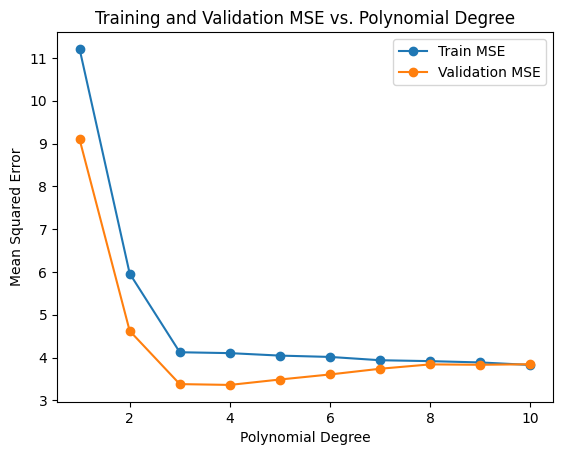

In [ ]:
#========================================================================
# (a) Split the dataset into a training set (70%) and a validation set (30%)
#========================================================================
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)


#========================================================================================================================================================
# (b) For polynomial degrees d ∈ {1, 2, 3, 4, 5, 6, 7, 8, 9, 10}, fit a polynomial regression model (with-out regularization) using the training data.
# For each d, compute the Mean Squared Error(MSE) on both the training and validation sets.
# Plot the training and validation MSE as functions of d, and use the plot to select an appropriate degree d∗ that balances underfitting and overfitting.
#=========================================================================================================================================================

ply_degree = range(1,11)
train_mse = []
val_mse = []

# training pipeline
for i in range(1,11):
  model = Pipeline([('poly', PolynomialFeatures(degree=i)),
                  ('linear', LinearRegression())])
  model.fit(X_train,y_train)
  y_pred_train = model.predict(X_train)
  y_pred_val = model.predict(X_test)
  train_mse.append(mean_squared_error(y_train,y_pred_train))
  val_mse.append(mean_squared_error(y_test,y_pred_val))

#visualization
plt.plot(ply_degree, train_mse, marker='o', label='Train MSE')
plt.plot(ply_degree, val_mse, marker='o', label='Validation MSE')
plt.legend()
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Training and Validation MSE vs. Polynomial Degree')


In [ ]:
expected_degree = '''
1. After polynomial degree 3 training losses goes constant.
2. At polynomial degree 3 validation losses is minimum then start increasing then goes constant after 8 degree.
3. Hence , polynomial degree = 3 will be right choice to make which balance overfitting and underfitting
'''
print(expected_degree)
print(f"polynomial degree :{np.argmin(val_mse)}")


1. After polynomial degree 3 training losses goes constant.
2. At polynomial degree 3 validation losses is minimum then start increasing then goes constant after 8 degree.
3. Hence , polynomial degree = 3 will be right choice to make which balance overfitting and underfitting

polynomial degree :3


In [ ]:
#========================================================================================================
# (c) For the chosen degree d∗, fit the following regularized polynomial models using the training data:
# i. Ridge regression with λ ∈ {10−4, 10−3, 10−2, 10−1, 1, 10}
# ii. Lasso regression with λ ∈ {10−4, 10−3, 10−2, 10−1, 1, 10}
# Use K-fold cross-validation on the training set to select the best λ for each method.
#=========================================================================================================

# ridge implementation
lembdas = [1e-4,1e-3,1e-2,1e-1,1,10]
kf = KFold(n_splits=4,shuffle=True,random_state=42)
train_mse_ridge = {}

for lembda_ in lembdas:
  model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                    ('scaler', StandardScaler()),
                    ('ridge', Ridge(alpha=lembda_))])
  cv_mse = -np.mean(cross_val_score(
    model, X_train, y_train,
    scoring="neg_mean_squared_error", cv=kf
    ))
  train_mse_ridge[lembda_] = cv_mse

print("=="*30)
print(f"result over lembdas : {train_mse_ridge}")
print(f"Best regularization rate for Ridge : {min(train_mse_ridge, key=train_mse_ridge.get)}")

result over lembdas : {0.0001: np.float64(4.5128357480456325), 0.001: np.float64(4.512827667790142), 0.01: np.float64(4.512747023235162), 0.1: np.float64(4.5119562537735725), 1: np.float64(4.505503692774684), 10: np.float64(4.530587837133913)}
Best regularization rate for Ridge : 1


In [ ]:
# lasso  implementation
lembdas = [1e-4,1e-3,1e-2,1e-1,1,10]
kf = KFold(n_splits=4,shuffle=True,random_state=42)
train_mse_lasso = {}

for lembda_ in lembdas:
  model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                    ('scaler', StandardScaler()),
                    ('ridge', Lasso(alpha=lembda_,max_iter=10000))])
  cv_mse = -np.mean(cross_val_score(
    model, X_train, y_train,
    scoring="neg_mean_squared_error", cv=kf
    ))
  train_mse_lasso[lembda_] = cv_mse

print("=="*30)
print(f"result over lembdas : {train_mse_lasso}")
print(f"Best regularization rate Lasso : {min(train_mse_lasso, key=train_mse_lasso.get)}")

result over lembdas : {0.0001: np.float64(4.5128387805536), 0.001: np.float64(4.512901530091613), 0.01: np.float64(4.5147162325602315), 0.1: np.float64(4.551197794480858), 1: np.float64(6.749467137131153), 10: np.float64(44.23238253314044)}
Best regularization rate Lasso : 0.0001


In [ ]:
# =====================================================================
# (d) For each method above (Ridge, Lasso), report:
# - The selected λ
# - Training MSE and cross-validation MSE
# - Validation set MSE using the final model
# - Estimated model coefficients
#======================================================================


# Ridge  model with regualization rate = 1
ridge_model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                    ('scaler', StandardScaler()),
                    ('ridge', Ridge(alpha=1))])
ridge_model.fit(X_train,y_train)
ridge_train_mse = mean_squared_error(y_train, ridge_model.predict(X_train))
ridge_val_mse = mean_squared_error(y_test, ridge_model.predict(X_test))
coefficients_ridge = ridge_model.named_steps['ridge'].coef_


print(f"model metrics : ...")
print("=="*30)
print(f"Ridge train mse : {ridge_train_mse}")
print(f"regulaeization rate at 1  cross-validation MSE : {min(train_mse_ridge.values())} ")
print(f"Ridge val mse : {ridge_val_mse}")
print(f"model coefficients : {coefficients_ridge}")

model metrics : ...
Ridge train mse : 4.123334263841076
regulaeization rate at 1  cross-validation MSE : 4.505503692774684 
Ridge val mse : 3.377172119372476
model coefficients : [ 0.          2.44837058 -2.23784056  3.48737338]


In [ ]:

# Lasso  model with regualization rate = 0.0001
lasso_model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                    ('scaler', StandardScaler()),
                    ('lasso', Lasso(alpha=0.0001,max_iter=10000))])
lasso_model.fit(X_train,y_train)
lasso_train_mse = mean_squared_error(y_train, lasso_model.predict(X_train))
lasso_val_mse = mean_squared_error(y_test, lasso_model.predict(X_test))
coefficients_lasso = lasso_model.named_steps['lasso'].coef_


print(f"model metrics : ...")
print("=="*30)
print(f"Lasso train mse : {lasso_train_mse}")
print(f"regularization rate at 0.0001  cross-validation MSE : {min(train_mse_lasso.values())}")
print(f"Lasso val mse : {lasso_val_mse}")
print(f"model coefficients : {coefficients_lasso}")

model metrics : ...
Lasso train mse : 4.122866264488167
regularization rate at 0.0001  cross-validation MSE : 4.5128387805536
Lasso val mse : 3.378175300935143
model coefficients : [ 0.          2.42549745 -2.24784303  3.52478859]



  i. Best Regularization Method : Ridge Regression i.e. L2 regularization seems better performing as having less validation loss as compare to Lasso i.e. L1 regularization.
  ii.L2 regularization improves generalization relative to the unregularized polynomial model by penalizing the large make , reducing overfitting thus reduce model complexity.
  iii.Choosing the right regularizer is important , ridge i.e. L2 : shrink the weight and penalize the larger error. and in L1 weight can goto zero and produce sparse model.



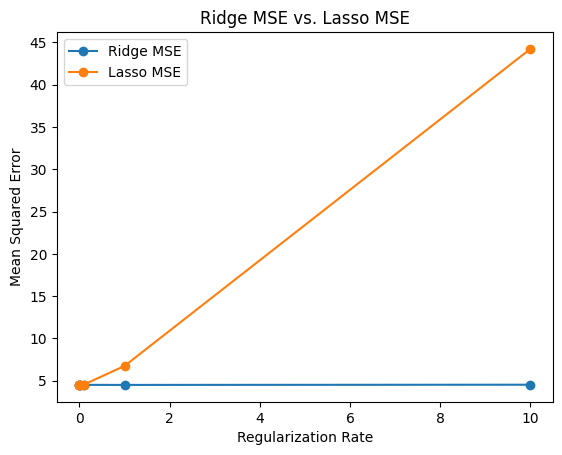

In [ ]:
#=========================================================================================================================================
# (e) Based on your results:
# i. Which regularization method performs best on the validation set ?Explain why.
# ii. Does regularization improve generalization relative to the unregularized polynomial model? Justify using the plots and error values.
# iii. Discuss how the chosen regularizer affects model complexity and coefficient estimates.
#==========================================================================================================================================

#visualization
plt.plot(train_mse_ridge.keys(), train_mse_ridge.values(), marker='o', label='Ridge MSE')
plt.plot(train_mse_lasso.keys(), train_mse_lasso.values(), marker='o', label='Lasso MSE')
plt.legend()
plt.xlabel('Regularization Rate')
plt.ylabel('Mean Squared Error')
plt.title('Ridge MSE vs. Lasso MSE')

obserbation = """
  i. Best Regularization Method : Ridge Regression i.e. L2 regularization seems better performing as having less validation loss as compare to Lasso i.e. L1 regularization.
  ii.L2 regularization improves generalization relative to the unregularized polynomial model by penalizing the large make , reducing overfitting thus reduce model complexity.
  iii.Choosing the right regularizer is important , ridge i.e. L2 : shrink the weight and penalize the larger error. and in L1 weight can goto zero and produce sparse model.
"""
print(obserbation)